In [104]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# Data Acquisition

In [12]:
FILENAME = "toward_a_goal"

In [13]:
df = pd.read_csv(FILENAME+".csv")
print(list(df.columns))

['time', 'cargo x', 'cargo y', 'cargo z', 'cargo alpha', 'cargo beta', 'cargo gamma', 'phi1', 'phi2', 'phi3', 'phi4', 'current1', 'current2', 'current3', 'current4', 'r1 x', 'r1 y', 'r1 z', 'r2 x', 'r2 y', 'r2 z', 'r3 x', 'r3 y', 'r3 z', 'r4 x', 'r4 y', 'r4 z']


# Plot Cargo Trajectory

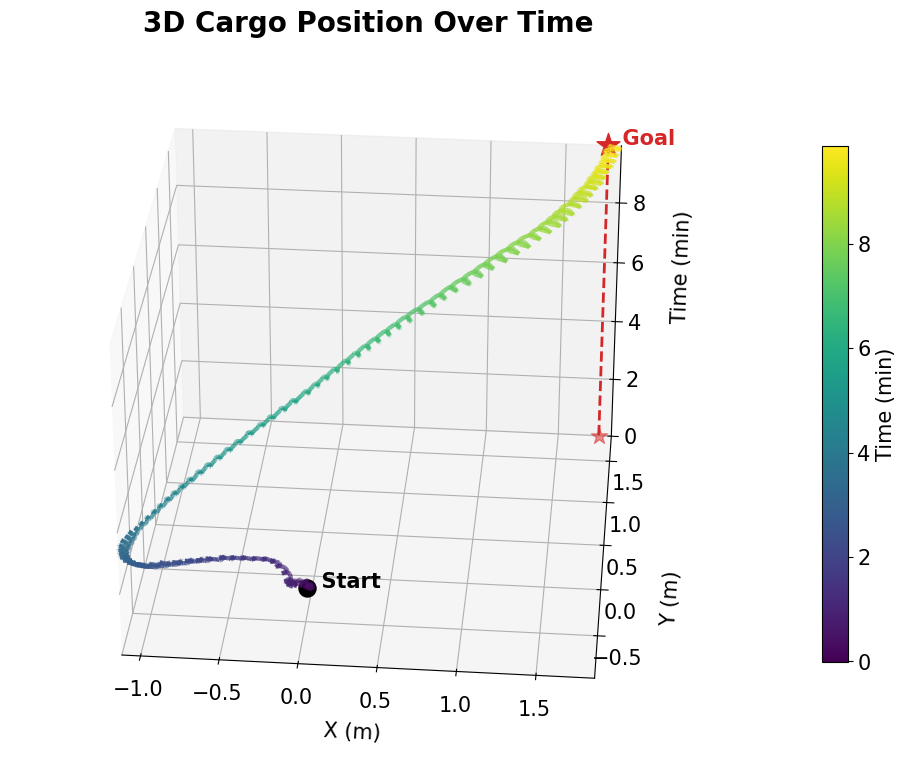

In [139]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Line3DCollection

# Set global default font size
plt.rcParams.update({"font.size": 15})

# 1. Prepare data
time = df["time"].to_numpy() / 20 / 60
cargo_position = df[["cargo x", "cargo y"]].to_numpy()

# Extract key coordinates
start_x, start_y, start_z = cargo_position[0, 0], cargo_position[0, 1], time[0]
goal_x, goal_y, goal_z = cargo_position[-1, 0], cargo_position[-1, 1], time[-1]

# 2. Setup 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# 3. Create color gradient line using Line3DCollection
points = np.array([cargo_position[:, 0], cargo_position[:, 1], time]).T.reshape(-1, 1, 3)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

lc = Line3DCollection(
    segments,
    cmap="viridis",
    norm=plt.Normalize(time.min(), time.max()),
)
lc.set_array(time)
lc.set_linewidth(3)
line = ax.add_collection(lc)

# Colorbar to show time mapping
cbar = fig.colorbar(line, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label("Time (min)", fontsize=15)
cbar.ax.tick_params(labelsize=15)

# Set axes limits (required when using collections in 3D)
ax.set_xlim(cargo_position[:, 0].min(), cargo_position[:, 0].max())
ax.set_ylim(cargo_position[:, 1].min(), cargo_position[:, 1].max())
ax.set_zlim(0, time.max())

# 4. Scatter and label START point
ax.scatter(
    start_x,
    start_y,
    start_z,
    color="k",
    marker="o",
    s=150,
    zorder=5,
    label="Start",
)
ax.text(
    start_x,
    start_y,
    start_z,
    "  Start",
    color="k",
    fontsize=15,
    fontweight="bold",
)

# 5. Scatter and label GOAL point
ax.scatter(
    goal_x,
    goal_y,
    goal_z,
    color="tab:red",
    marker="*",
    s=300,
    zorder=5000,
    label="Goal",
)
ax.text(
    goal_x,
    goal_y,
    goal_z,
    "  Goal",
    color="tab:red",
    fontsize=15,
    fontweight="bold",
)

# 6. Vertical line from Goal down to z = 0
ax.plot(
    [goal_x, goal_x],
    [goal_y, goal_y],
    [goal_z, 0],
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label="Goal Projection (z=0)",
)

ax.scatter(
    goal_x,
    goal_y,
    0,
    color="tab:red",
    marker="*",
    s=150,
    alpha=0.5,
)

# 7. Labels & Polish
ax.set_xlabel("X (m)", fontsize=15, labelpad=10)
ax.set_ylabel("Y (m)", fontsize=15, labelpad=20)
ax.set_zlabel("Time (min)", fontsize=15, labelpad=18)
ax.set_title("3D Cargo Position Over Time", fontsize=20, pad=10,fontweight='bold')

ax.tick_params(axis="both", which="major", labelsize=15)

ax.view_init(elev=30, azim=-85)
plt.tight_layout()
plt.show()

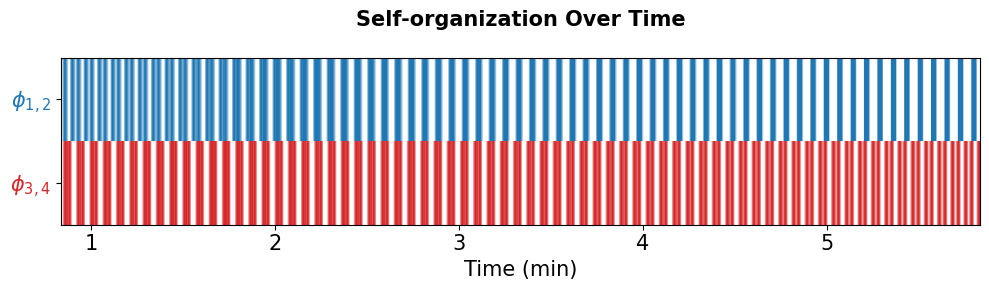

In [116]:



time = df["time"].to_numpy() / 20 / 60
phis = df[["phi"+str(i+1) for i in range(4)]].to_numpy()
forces = np.clip(np.sin(phis),0,1)


# 1. Combine forces and ensure values stay in [0, 1] range for colormaps
force_blue = np.clip(forces[:, 0] + forces[:, 1], 0, 1)  # phi1 & phi2
force_red = np.clip(forces[:, 2] + forces[:, 3], 0, 1)  # phi3 & phi4

# 2. Define custom colormaps
cmap_blue = mcolors.LinearSegmentedColormap.from_list(
    "white_blue", ["white", "tab:blue"]
)
cmap_red = mcolors.LinearSegmentedColormap.from_list(
    "white_red", ["white", "tab:red"]
)

# 3. Build a 2-row RGBA matrix of shape (2, N, 4)
rgba = np.zeros((2, forces.shape[0], 4))
rgba[0] = cmap_blue(force_blue)  # Combined phi1 & phi2
rgba[1] = cmap_red(force_red)  # Combined phi3 & phi4

# 4. Plot the 2-row array with 'extent' to scale x-axis by / 20 / 60
x_max = 8000 / 20 / 60  # Maps indices 0..8000 directly to time (min)

fig, ax = plt.subplots(figsize=(10, 3))
ax.imshow(
    rgba, interpolation="nearest", aspect="auto", extent=[0, x_max, 1.5, -0.5]
)

# 5. Set y-ticks and customize label colors
ax.set_yticks([0, 1])
ax.set_yticklabels([r"$\phi_{1,2}$", r"$\phi_{3,4}$"], fontsize=15)

yticks = ax.get_yticklabels()
yticks[0].set_color("tab:blue")  # Set top label to blue
yticks[1].set_color("tab:red")  # Set bottom label to red

ax.set_xlabel("Time (min)", fontsize=15)
ax.tick_params(axis="both", labelsize=15)

ax.set_title("Self-organization Over Time\n", fontsize=15,fontweight='bold')
ax.set_xlim([1000/20/60,7000/20/60])
plt.tight_layout()
plt.show()